<a href="https://colab.research.google.com/github/Bluestar0000/dfu-gradcam-shap/blob/main/GradCam%26SHAP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install grad-cam shap opencv-python matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 32.5 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for grad-cam: filename=grad_cam-1.5.5-py3-none-any.whl size=44285 sha256=b0b5ceb338adda4e384c920081d96edbd9dfe4192068f2ceef2d2db123f7d5ba
  Stored in directory: /root/.cache/pip/wheels/fb/3b/09/2afc520f3d69bc26ae6bd87416759c820a3f7d05c1a077bbf6
Successfully built grad-cam


In [5]:
import numpy as np
import cv2
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam import ScoreCAM
from pytorch_grad_cam import GradCAMPlusPlus
from pytorch_grad_cam.utils.image import show_cam_on_image

def generate_gradcam(cam, input_tensor):
      grayscale_cam = cam(input_tensor=input_tensor)
      heatmap = grayscale_cam[0]
      return heatmap
def initialize_gradcam(model, target_layer):
      cam = GradCAM(
      model=model,
      target_layers=[target_layer]
          )

      return cam

In [15]:
import torch
import torch.nn as nn
import torchvision.models as models
from torchvision import transforms
import shap

transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224,224)),
    transforms.ToTensor()
])
def load_model(model_path):
    model = models.resnet50(pretrained=False)
    model.fc = nn.Linear(model.fc.in_features, 2)

    model.load_state_dict(torch.load(model_path, map_location="cpu"))

    model.eval()

    return model

In [13]:
import torch

path = "/content/dfu_model_v1.pth"

data = torch.load(path, map_location="cpu")

print(type(data))
print(data.keys() if isinstance(data, dict) else "Not a dict")

<class 'collections.OrderedDict'>
odict_keys(['features.0.0.weight', 'features.0.1.weight', 'features.0.1.bias', 'features.0.1.running_mean', 'features.0.1.running_var', 'features.0.1.num_batches_tracked', 'features.1.0.block.0.0.weight', 'features.1.0.block.0.1.weight', 'features.1.0.block.0.1.bias', 'features.1.0.block.0.1.running_mean', 'features.1.0.block.0.1.running_var', 'features.1.0.block.0.1.num_batches_tracked', 'features.1.0.block.1.fc1.weight', 'features.1.0.block.1.fc1.bias', 'features.1.0.block.1.fc2.weight', 'features.1.0.block.1.fc2.bias', 'features.1.0.block.2.0.weight', 'features.1.0.block.2.1.weight', 'features.1.0.block.2.1.bias', 'features.1.0.block.2.1.running_mean', 'features.1.0.block.2.1.running_var', 'features.1.0.block.2.1.num_batches_tracked', 'features.2.0.block.0.0.weight', 'features.2.0.block.0.1.weight', 'features.2.0.block.0.1.bias', 'features.2.0.block.0.1.running_mean', 'features.2.0.block.0.1.running_var', 'features.2.0.block.0.1.num_batches_tracked'

In [3]:
import os
def gradcam_plus(model, target_layer, input_tensor):
    cam = GradCAMPlusPlus(model=model, target_layers=[target_layer])
    grayscale_cam = cam(input_tensor=input_tensor)[0]
    return grayscale_cam
def preprocess_image(img):
    input_tensor = transform(img).unsqueeze(0)
    return input_tensor
def load_test_images(folder):

    image_paths = []

    for root, dirs, files in os.walk(folder):

        for file in files:

            if file.endswith(".jpg") or file.endswith(".png"):

                image_paths.append(os.path.join(root,file))

    return image_paths
def preprocess_image(img):

    input_tensor = transform(img).unsqueeze(0)

    return input_tensor

In [2]:
def overlay_heatmap(img, heatmap):
  heatmap = cv2.resize(heatmap,(img.shape[1],img.shape[0]))
  heatmap = np.uint8(255 * heatmap)
  heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
  overlay = heatmap * 0.4 + img * 0.6
  return overlay

In [1]:
import shap

def shap_explanation(model, input_tensor):
    background = input_tensor[:1]
    explainer = shap.GradientExplainer(model, background)
    shap_values = explainer.shap_values(input_tensor)
    return shap_values

def plot_shap(shap_values, input_tensor):
    shap.image_plot(shap_values, input_tensor.detach().numpy())

In [23]:
from google.colab import files
uploaded=files.upload()

Saving foot_ulcer_5.jpg to foot_ulcer_5.jpg
Saving Footpuncture-blog2.jpg to Footpuncture-blog2.jpg
Saving Foot-ulcer-600x399.png to Foot-ulcer-600x399.png
Saving foot-ulcer-pic (1).png to foot-ulcer-pic (1).png
Saving foot-ulcer-pic.png to foot-ulcer-pic.png
Saving GettyImages-840167308-1-650x450.jpg to GettyImages-840167308-1-650x450.jpg
Saving hallux-IPJ-ulcer-post1A.jpg to hallux-IPJ-ulcer-post1A.jpg
Saving honey1.jpg to honey1.jpg
Saving how-to-heal-a-diabetic-foot-ulcer-700393-2.jpg to how-to-heal-a-diabetic-foot-ulcer-700393-2.jpg
Saving image1.jpeg to image1.jpeg
Saving image3.jpeg to image3.jpeg
Saving image4.jpeg to image4.jpeg
Saving images (1).jpg to images (1).jpg
Saving images (2).jpg to images (2).jpg
Saving images (3).jpg to images (3).jpg
Saving images (4).jpg to images (4).jpg
Saving images (5).jpg to images (5).jpg
Saving images (6).jpg to images (6).jpg
Saving images (7).jpg to images (7).jpg
Saving images (8).jpg to images (8).jpg
Saving images (9).jpg to images (9

In [6]:
import glob

images = glob.glob("/content/*.jpg") + glob.glob("/content/*.png") + glob.glob("/content/*.jpeg")

print("Total images found:", len(images))
import torchvision.models as models

model = models.resnet50(pretrained=True)

for module in model.modules():
    if isinstance(module, torch.nn.ReLU):
        module.inplace = False

model.eval()

target_layer = model.layer4[-1]

cam = initialize_gradcam(model, target_layer)

Total images found: 163


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Processing: /content/diabetic-foot-ulcer (1).jpg
Prediction: 419


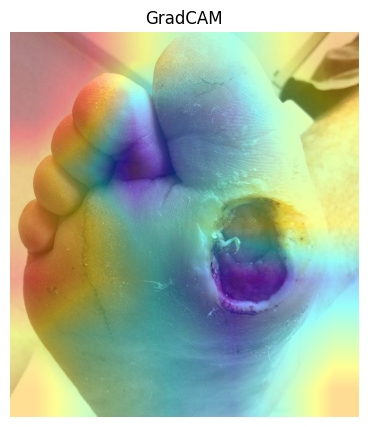

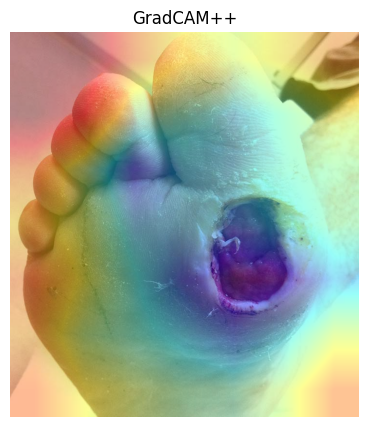

Processing: /content/5.jpg
Prediction: 435


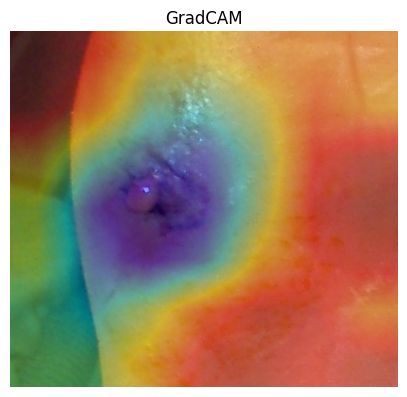

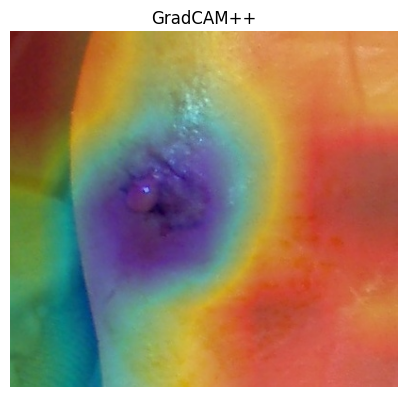

Processing: /content/0.jpg
Prediction: 942


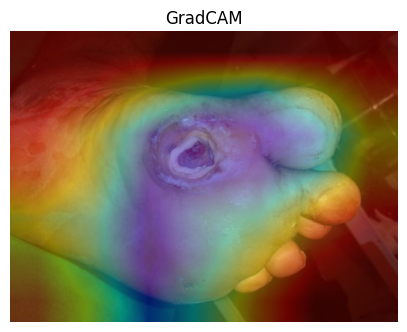

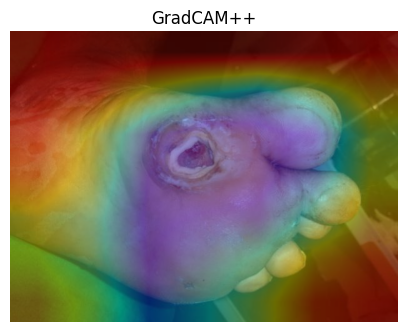

Processing: /content/afp19980315p1325-f4.jpg
Prediction: 961


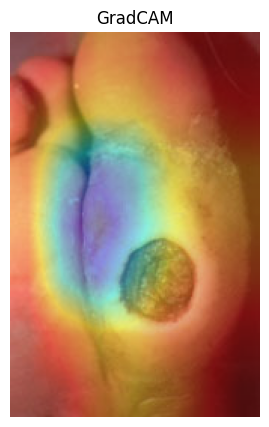

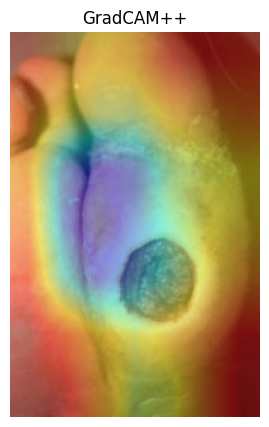

Processing: /content/images (31).jpg
Prediction: 739


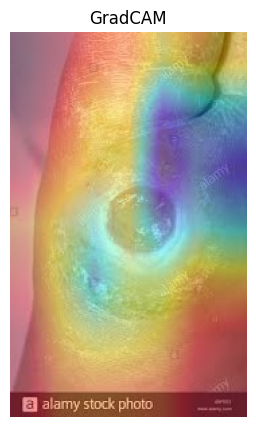

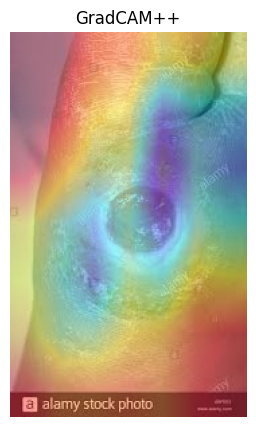

In [16]:
import matplotlib.pyplot as plt
for path in images[:5]:

    print("Processing:", path)

    img = cv2.imread(path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    input_tensor = preprocess_image(img)
    output = model(input_tensor)
    pred = torch.argmax(output, dim=1)

    print("Prediction:", pred.item())
    heatmap = generate_gradcam(cam, input_tensor)
    overlay = overlay_heatmap(img, heatmap)

    plt.figure(figsize=(5,5))
    plt.imshow(overlay.astype(np.uint8))
    plt.title("GradCAM")
    plt.axis("off")
    plt.show()
    heatmap_plus = gradcam_plus(model, target_layer, input_tensor)
    overlay_plus = overlay_heatmap(img, heatmap_plus)

    plt.figure(figsize=(5,5))
    plt.imshow(overlay_plus.astype(np.uint8))
    plt.title("GradCAM++")
    plt.axis("off")
    plt.show()



In [17]:
path = images[0]

img = cv2.imread(path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

input_tensor = preprocess_image(img)

shap_values = shap_explanation(model, input_tensor)

plot_shap(shap_values, input_tensor)

KeyboardInterrupt: 

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))
plt.subplot(1,3,1)
plt.imshow(img)
plt.title("Original Image")
plt.axis("off")
plt.subplot(1,3,2)
plt.imshow(overlay.astype(np.uint8))
plt.title("GradCAM")
plt.axis("off")
plt.subplot(1,3,3)
plt.imshow(overlay_plus.astype(np.uint8))
plt.title("GradCAM++")
plt.axis("off")

plt.tight_layout()
plt.show()